### Imports, measurement simulation, Zero-Filled and GRAPPA/SENSE reconstruction

In [3]:
import torch
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from mrinufft import get_operator
from mrinufft.io import read_trajectory
from mrinufft.extras.smaps import get_smaps
from baselines.grappa_reconstruction import do_grappa_and_append_data
from utils import MRINUFFTPhysicsRI, ri_to_complex, complex_to_ri, sum_of_squares, _load_volumes, L2_precon, get_acs_locations
from reg_architecture import WCRR3D, WCRR3D_eval
from evaluation.nmAPG3d_evaluation import reconstruct_nmAPG
import os
import warnings
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
torch.random.manual_seed(0)  # make results deterministic

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backend = "cufinufft"#"gpunufft"
scaler = 1e-6 
noise_level = 2e-3
init = "grappa" # "grappa" or "sense". Whether to initialize the solver with a GRAPPA reconstruction of the center of k-space, or with a SENSE reconstruction. The former is the default and the one used in the paper, but you can change it to see how it affects convergence and recon quality.

# Load trajectory and get the k-space locations
traj_name = "gs.bin"
traj, traj_params = read_trajectory(traj_name, dwell_time=0.01/2)
traj = traj.copy()
traj[traj < -0.5] = -0.5
traj[traj > 0.5] = 0.5
dim = traj_params["dimension"]
kspace_loc = traj.reshape(-1, dim)
if traj_name != "gs.bin": # for example "caipi.bin", and it would need a different initialization than GRAPPA
    acs_loc = get_acs_locations(img_size=traj_params['img_size'])
    kspace_loc = np.vstack([kspace_loc, acs_loc])

# The chosen volume
coils = 12 # number of coils in the volume (12 or 32)
root = f"../../../../../../../../LOCAL/mri_data/Test/{coils}coil" # replace with the path to the folder containing the volumes. The 12-coil volumes are in Test/12coil, and the 32-coil volumes are in Test/32coil
volume = "e14091s3_P67584.7.h5"#'e14091s3_P67584.7.h5' if coils==12 else 'e16324s3_P17408.7.h5' # The latter is a 32-coil volume
x = torch.from_numpy(scaler * np.moveaxis(_load_volumes(os.path.join(root, volume)),-1, 0)) #[coils,H,W,D] and complex dtype

# Forward NUFFT that takes coil images -> k-space
print(f"Simulation of the undersampled measurement!")
print("Start ... ")
F_raw = get_operator(backend)(kspace_loc, x.shape[1:], n_coils=coils, density=True, squeeze_dims=True)
y_np = F_raw.op(x) # simulates the undersampled kspace volume y. The zero-filled recon comes from it
y_np = y_np + noise_level * torch.randn_like(y_np)
print("Succesfully simulated!")

# Build reconstruction operator that ESTIMATES smaps from y_grappa
print(f"Operator definition and smaps estimation from measurement!")
print("Start ... ")

data_fidelity = L2_precon(weights=torch.tensor(1.0)) # custom data fidelity

Smaps = get_smaps("espirit")(
    kspace_loc,
    x.shape[1:],
    kspace_data=cp.asarray(y_np),
    density=F_raw.density,
    backend=backend,
    decim=4,
)
print(Smaps.get().shape)

E_est = get_operator(backend)(
    kspace_loc,#new_kspace_loc,
    x.shape[1:],
    n_coils=coils,
    smaps=Smaps.get(),
    squeeze_dims=True
)
physics = MRINUFFTPhysicsRI(E_est)
print("Succesfull!")

y = y_np.to(device) # zf (zero-filled) measurement in the k-space
x_adj_ri = physics.A_adjoint(y) #zf recon in the RI space

# Reference/Ground Truth (Adjoint coil combination)
smaps = torch.from_numpy(E_est.smaps)

x_gt = torch.sum(torch.conj(smaps) * x, axis=0)
x_gt_ri = complex_to_ri(x_gt).to(device) # In the RI space

# Compute the magnitudes
reference = torch.abs(ri_to_complex(x_gt_ri)).detach().cpu()
if init=="grappa":
    # GRAPPA reconstruct the center of k-space and append the data, basis for our regularizers
    new_kspace_loc, y_grappa = do_grappa_and_append_data(kspace_loc, y_np, traj_params, af=(2, 2), acs=None)
    y_grappa = torch.from_numpy(y_grappa).to(device) # ACS reconstructed with grappa (In the k-space)
    # Grappa + DCp recon
    nufft_grappa = get_operator(backend)(new_kspace_loc, x.shape[1:], n_coils=coils, smaps=Smaps.get(), density=True, squeeze_dims=True)
    dcp_grappa_ri = complex_to_ri(nufft_grappa.adj_op(y_grappa)) #physics.A_adjoint(weights * y_grappa)#y)
    grappa_recon  = torch.abs(ri_to_complex(dcp_grappa_ri)).detach().cpu()
else: # init=="sense"
    sense_ri = physics.A_dagger(y)
    sense_recon = torch.abs(ri_to_complex(sense_ri)).detach().cpu()
    
# Handle the zero-filled + DCp recon
x_zf = F_raw.adj_op(y_np) #zero-filled reconstruction
zf_recon = sum_of_squares(x_zf) # Its magnitude

Simulation of the undersampled measurement!
Start ... 
Succesfully simulated!
Operator definition and smaps estimation from measurement!
Start ... 


  0%|          | 0/10 [00:00<?, ?it/s]

(12, 256, 218, 170)
Succesfull!


100%|██████████| 77/77 [00:01<00:00, 73.38it/s]


In [4]:
# To clean up memory a little bit (optional, depending on your hardware)
import gc
# delete big objects you don't need anymore
#del E_est, Smaps, x, F_raw, y_np, kspace_loc, x_zf #, new_kspace_loc, y_grappa, nufft_grappa
gc.collect
# clear PyTorch caching allocator
torch.cuda.empty_cache()
# clear any leftover cached graph memory
torch.cuda.ipc_collect()
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

### WCRR reconstruction (rotation-invariant version)

In [5]:
# Load the regularizer weights
reg = WCRR3D(weak_convexity=1.0, nb_channels=[2,4,8,32], filter_sizes=[3, 3, 3], rotations=True, device=device).to(device)
pretrained = "weights/bilevel_Denoising/WCRR_500_bilevel_IFT_ckpt_500.pt"
reg.load_state_dict(torch.load(pretrained, weights_only=True, map_location=device))
reg.eval()

# Parameters of nmAPG solver
step_size = 1e-1
max_iter = 100
tol = 1e-7 # Solely for plotting convergence curves across 100 iterations, the normal stopping criterion is tol = 5e-3

# Regularization parameters
lmbd = 0.01
sigma = 0.03
sigma = torch.tensor([sigma], device=device)

# Evaluation setting
regularizer = WCRR3D_eval(
        conv_lip=reg.get_conv_lip(),
        beta=torch.exp(reg.beta),
        scaling_sigma=reg.scaling(sigma),
        filters=reg.filters,
        effective_filters=False, # Wether to use the effective filters or not
        rotations=True,
    )

with torch.no_grad():
    x_rec_ri, wcrr_metrics = reconstruct_nmAPG(
                sigma,
                y,
                physics,
                data_fidelity,
                regularizer,
                lmbd,
                step_size,
                max_iter,
                tol,
                verbose=True,
                x_init=dcp_grappa_ri, # Initialize with GRAPPA recon
                x_gt=x_gt_ri,
                return_stats=True,
                )
# Its Magnitude
wcrr_recon  = torch.abs(ri_to_complex(x_rec_ri)).detach().cpu()

100%|██████████| 100/100 [08:35<00:00,  5.16s/it]


max iter reached, tol 0.000130


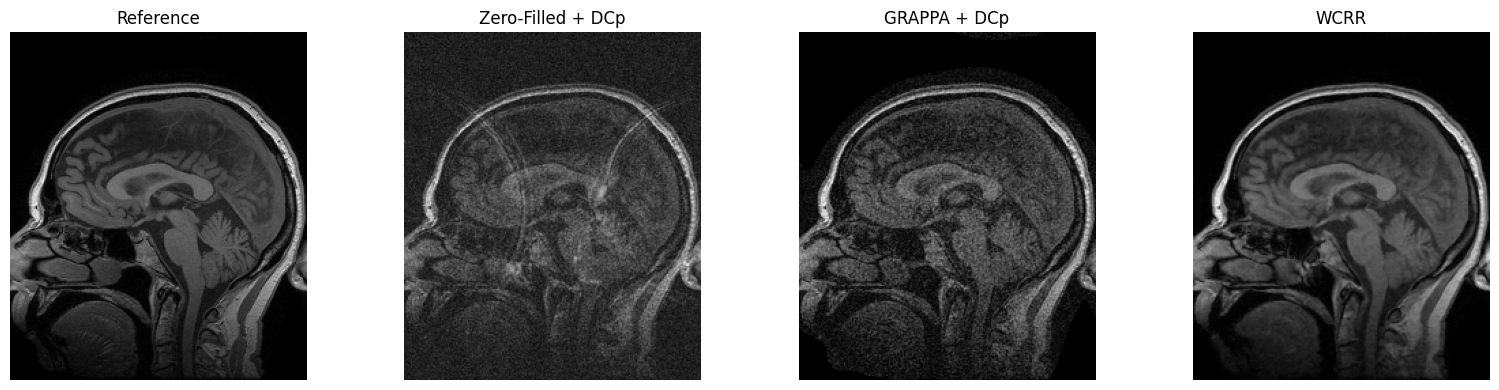

In [6]:
# Plots (sagittal mid-slice)
mid =  reference.shape[-1] // 2
plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(reference[..., mid], cmap='gray'); plt.title('Reference'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(zf_recon[..., mid],  cmap='gray'); plt.title('Zero-Filled + DCp'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(grappa_recon[..., mid],  cmap='gray'); plt.title('GRAPPA + DCp'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(wcrr_recon[..., mid],  cmap='gray'); plt.title('WCRR'); plt.axis('off')
plt.tight_layout(); plt.show()

#### Convergence curves

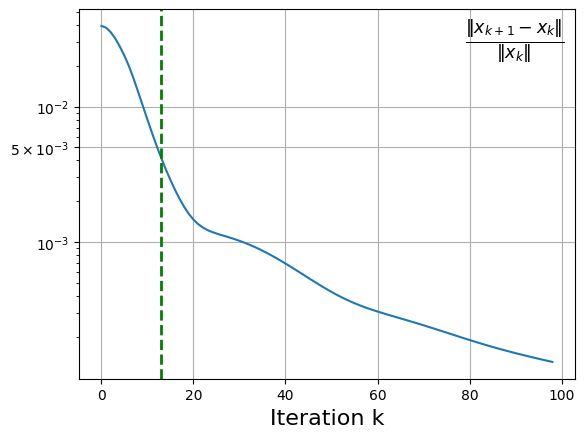

In [8]:
fig, ax = plt.subplots()

ax.plot(wcrr_metrics['residual'])
ax.grid(True)
ax.set_xlabel("Iteration k", fontsize=16)
ax.set_ylabel(r"$\frac{\|x_{k+1}-x_k\|}{\|x_k\|}$", fontsize=18, fontweight="bold", rotation=0, ha="right", va="top")
ax.yaxis.set_label_coords(0.98, 0.98)
ax.set_yscale("log")
# y-ticks
ax.set_yticks([1e-2, 5e-3, 1e-3])
ax.set_yticklabels([r"$10^{-2}$", r"$5\times10^{-3}$", r"$10^{-3}$"])
# position of vertical line
k = 13   # Iteration at which the tolerance gets below 5e-3, which is the stopping criterion for the solver
# draw vertical line
ax.axvline(k, color="green", linestyle="--", lw=2)
plt.savefig(f"savings_{coils}coil_gs/residuals_{coils}coil_example.pdf", bbox_inches='tight')
plt.show()

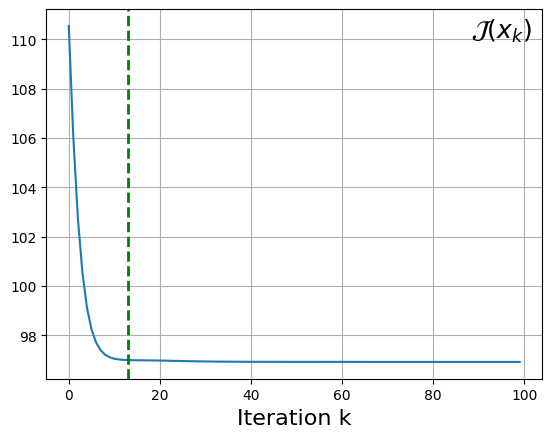

In [9]:
fig, ax = plt.subplots()

ax.plot(wcrr_metrics['cost'])
ax.grid(True)
ax.set_xlabel("Iteration k", fontsize=16)
ax.set_ylabel(r"$\mathcal{J}(x_k)$", fontsize=18, fontweight="bold", rotation=0, ha="right", va="top")
plt.gca().yaxis.set_label_coords(0.98, 0.98)
# position of vertical line
k = 13   # Iteration at which the tolerance gets below 5e-3, which is the stopping criterion for the solver
# draw vertical line
ax.axvline(k, color="green", linestyle="--", lw=2)
plt.savefig(f"savings_{coils}coil_gs/energies_{coils}coil_example.pdf", bbox_inches='tight')
plt.show()

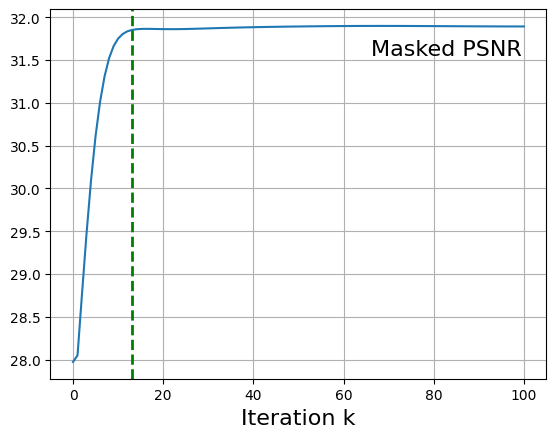

In [10]:
fig, ax = plt.subplots()

ax.plot(wcrr_metrics['psnr'])
ax.grid(True)
ax.set_xlabel("Iteration k", fontsize=16)
ax.set_ylabel(r"Masked PSNR", fontsize=16, rotation=0, ha="right", va="top")
plt.gca().yaxis.set_label_coords(0.95, 0.92)
# position of vertical line
k = 13   # Iteration at which the tolerance gets below 5e-3, which is the stopping criterion for the solver
# draw vertical line
ax.axvline(k, color="green", linestyle="--", lw=2)
plt.savefig(f"savings_{coils}coil_gs/psnrs_{coils}coil_example.pdf", bbox_inches='tight')
plt.show()